In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

Dataset Shape: (7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender 

In [ ]:

# Make a copy for cleaning
df_clean = df.copy()

# Convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Check missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Remove rows with missing TotalCharges
df_clean = df_clean.dropna(subset=["TotalCharges"])

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Convert SeniorCitizen to categorical labels
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

# Check the cleaned dataset
print("\nCleaned Dataset Shape:", df_clean.shape)

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows After Cleaning:")
print(df_clean.duplicated().sum())

display(df_clean.head())

Missing values before cleaning:
TotalCharges    11
dtype: int64

Cleaned Dataset Shape: (7032, 21)

Missing Values After Cleaning:
0

Duplicate Rows After Cleaning:
0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


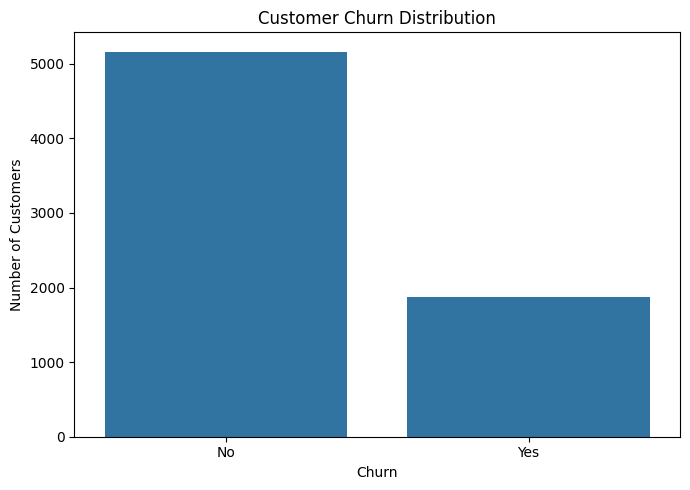


Churn Rate by Contract:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64


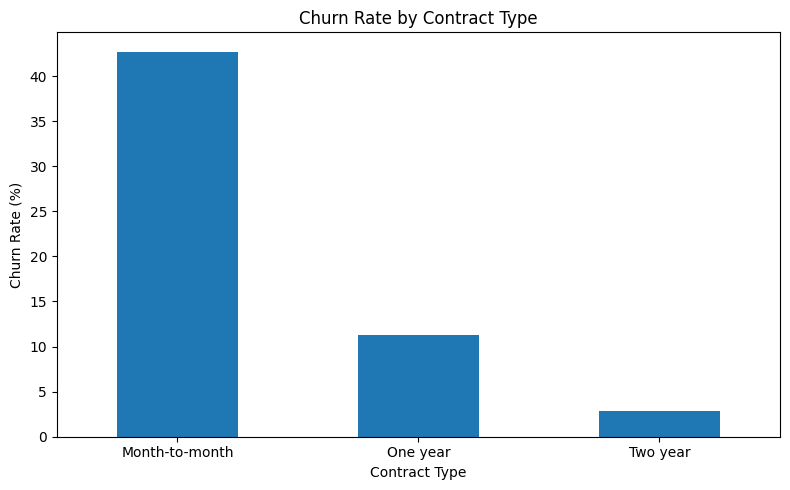


Churn Rate by Internet Service:
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Churn, dtype: float64


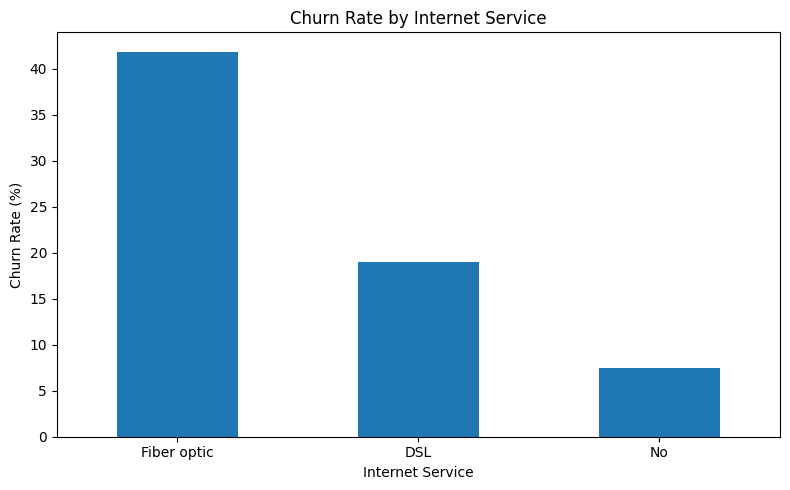


Churn Rate by Payment Method:
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Churn, dtype: float64


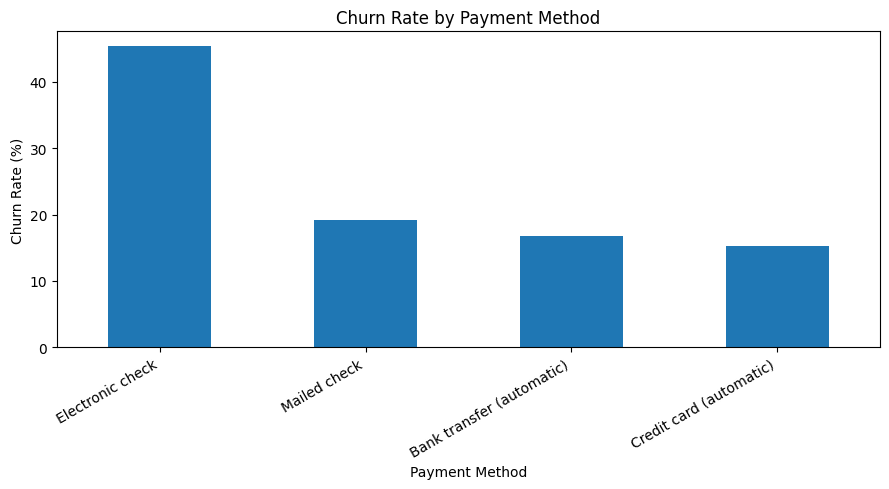

In [ ]:
# ==========================================
# TASK 3 — EXPLORATORY DATA ANALYSIS
# ==========================================

# Churn counts
print("Churn Distribution:")
print(df_clean["Churn"].value_counts())

print("\nChurn Percentage:")
print(
    (df_clean["Churn"].value_counts(normalize=True) * 100)
    .round(2)
)


# ------------------------------------------
# 1. Overall Churn Distribution
# ------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# ------------------------------------------
# 2. Churn Rate by Contract
# ------------------------------------------

contract_churn = (
    df_clean.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("\nChurn Rate by Contract:")
print(contract_churn.round(2))

plt.figure(figsize=(8, 5))

contract_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------
# 3. Churn Rate by Internet Service
# ------------------------------------------

internet_churn = (
    df_clean.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("\nChurn Rate by Internet Service:")
print(internet_churn.round(2))

plt.figure(figsize=(8, 5))

internet_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------
# 4. Churn Rate by Payment Method
# ------------------------------------------

payment_churn = (
    df_clean.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("\nChurn Rate by Payment Method:")
print(payment_churn.round(2))

plt.figure(figsize=(9, 5))

payment_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

Churn Rate by Tenure:


,Churn Rate (%)
tenure,
1,61.99
2,51.68
3,47.00
4,47.16
5,48.12
...,...
68,9.00
69,8.42
70,9.24


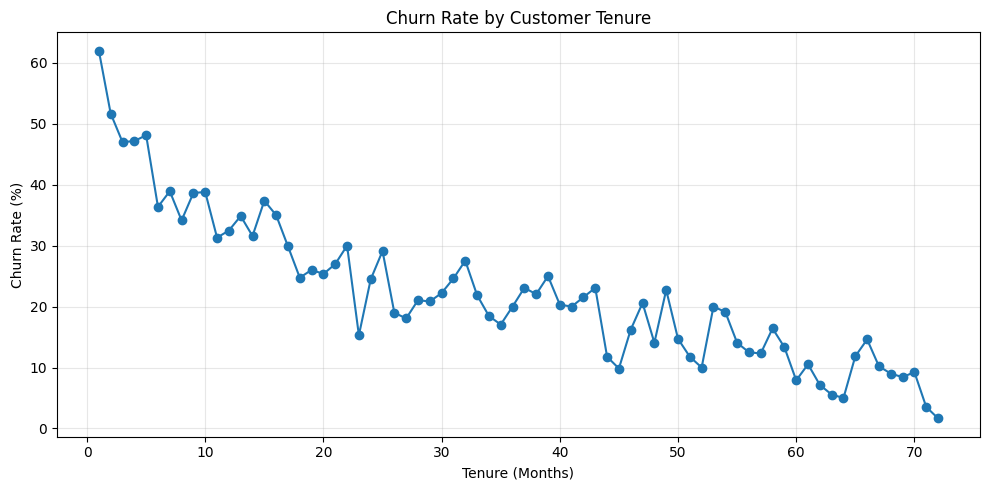

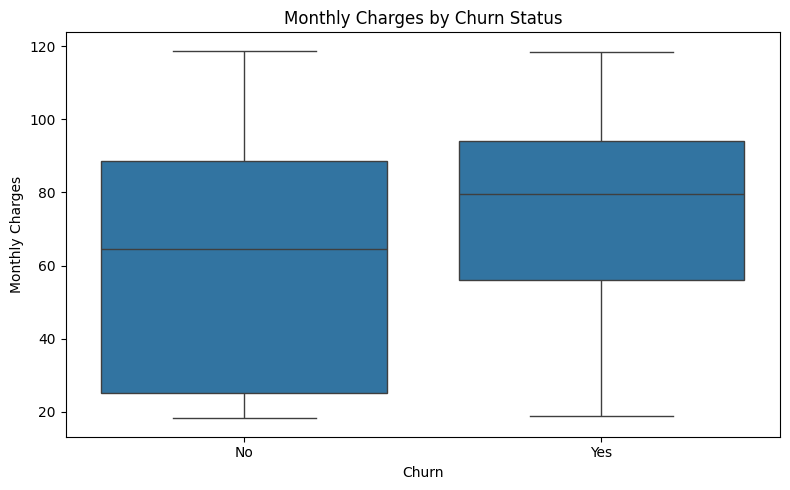

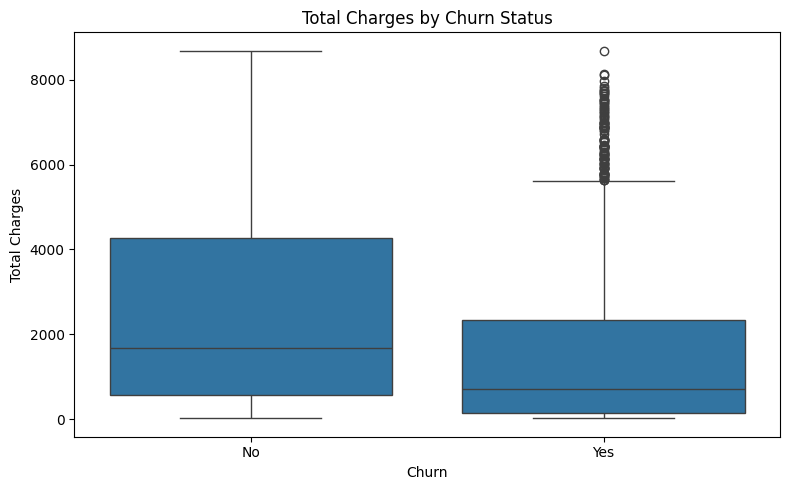

Customer Summary by Churn:


,Customers,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges
Churn,,,,
No,5163,37.65,61.31,2555.34
Yes,1869,17.98,74.44,1531.80


Churn Rate by Senior Citizen:


,Churn Rate (%)
SeniorCitizen,
No,23.65
Yes,41.68


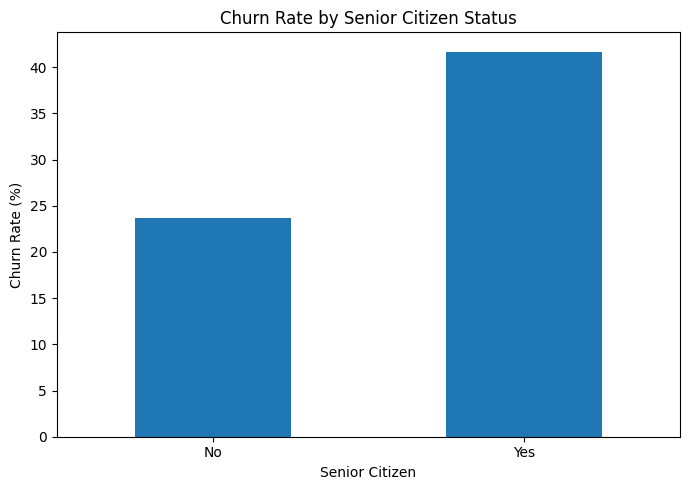

In [ ]:
# ==========================================
# TASK 4 — CUSTOMER BEHAVIOR ANALYSIS
# ==========================================

# Convert Churn to numeric for calculations
df_clean["Churn_Flag"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})


# ------------------------------------------
# 1. Churn Rate by Tenure
# ------------------------------------------

tenure_churn = (
    df_clean.groupby("tenure")["Churn_Flag"]
    .mean()
    .mul(100)
)

print("Churn Rate by Tenure:")
display(tenure_churn.round(2).to_frame("Churn Rate (%)"))


plt.figure(figsize=(10, 5))

plt.plot(
    tenure_churn.index,
    tenure_churn.values,
    marker="o"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------
# 2. Monthly Charges vs Churn
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()


# ------------------------------------------
# 3. Total Charges vs Churn
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()


# ------------------------------------------
# 4. Customer Summary
# ------------------------------------------

customer_summary = df_clean.groupby("Churn").agg(
    Customers=("customerID", "count"),
    Avg_Tenure=("tenure", "mean"),
    Avg_Monthly_Charges=("MonthlyCharges", "mean"),
    Avg_Total_Charges=("TotalCharges", "mean")
)

customer_summary = customer_summary.round(2)

print("Customer Summary by Churn:")
display(customer_summary)


# ------------------------------------------
# 5. Churn Rate by Senior Citizen
# ------------------------------------------

senior_churn = (
    df_clean.groupby("SeniorCitizen")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
)

print("Churn Rate by Senior Citizen:")
display(senior_churn.to_frame("Churn Rate (%)"))


plt.figure(figsize=(7, 5))

senior_churn.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Churn Rate by Tech Support:


,Churn Rate (%)
TechSupport,
No,41.65
Yes,15.20
No internet service,7.43


Churn Rate by Online Security:


,Churn Rate (%)
OnlineSecurity,
No,41.78
Yes,14.64
No internet service,7.43


Churn Rate by Contract:


...

,Churn Rate (%)
PhoneService,
Yes,26.75
No,25.00



Churn Rate by PaperlessBilling:


,Churn Rate (%)
PaperlessBilling,
Yes,33.59
No,16.38



Churn Rate by Number of Services:


,Churn Rate (%)
ServiceCount,
1,20.81
2,34.52
3,37.72
4,31.29
5,25.78
6,21.84
7,11.67
8,5.29


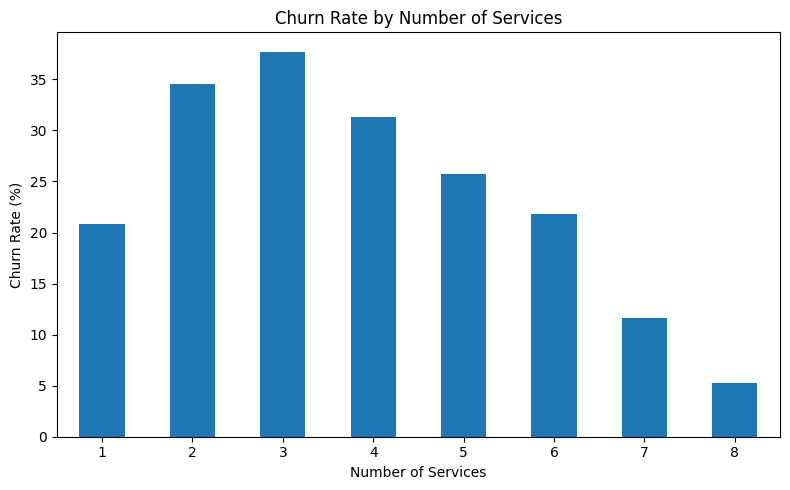

In [ ]:
# ==========================================
# TASK 5 — SERVICE & CUSTOMER SEGMENT ANALYSIS
# ==========================================

# ------------------------------------------
# 1. Churn Rate by Tech Support
# ------------------------------------------

support_churn = (
    df_clean.groupby("TechSupport")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Tech Support:")
display(support_churn.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 2. Churn Rate by Online Security
# ------------------------------------------

security_churn = (
    df_clean.groupby("OnlineSecurity")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Online Security:")
display(security_churn.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 3. Churn Rate by Contract
# ------------------------------------------

contract_churn = (
    df_clean.groupby("Contract")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract:")
display(contract_churn.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 4. Churn Rate by Customer Type
# ------------------------------------------

customer_type_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for column in customer_type_columns:

    result = (
        df_clean.groupby(column)["Churn_Flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(f"\nChurn Rate by {column}:")
    display(result.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 5. Service Count
# ------------------------------------------

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Count active/additional services
df_clean["ServiceCount"] = 0

for column in service_columns:
    df_clean["ServiceCount"] += (
        ~df_clean[column].isin(["No", "No internet service"])
    ).astype(int)


# ------------------------------------------
# 6. Churn Rate by Number of Services
# ------------------------------------------

service_churn = (
    df_clean.groupby("ServiceCount")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_index()
)

print("\nChurn Rate by Number of Services:")
display(service_churn.round(2).to_frame("Churn Rate (%)"))


plt.figure(figsize=(8, 5))

service_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Churn Rate by Tech Support:


,Churn Rate (%)
TechSupport,
No,41.65
Yes,15.20
No internet service,7.43


Churn Rate by Online Security:


,Churn Rate (%)
OnlineSecurity,
No,41.78
Yes,14.64
No internet service,7.43


Churn Rate by Contract:


...

,Churn Rate (%)
PhoneService,
Yes,26.75
No,25.00



Churn Rate by PaperlessBilling:


,Churn Rate (%)
PaperlessBilling,
Yes,33.59
No,16.38



Churn Rate by Number of Services:


,Churn Rate (%)
ServiceCount,
1,20.81
2,34.52
3,37.72
4,31.29
5,25.78
6,21.84
7,11.67
8,5.29


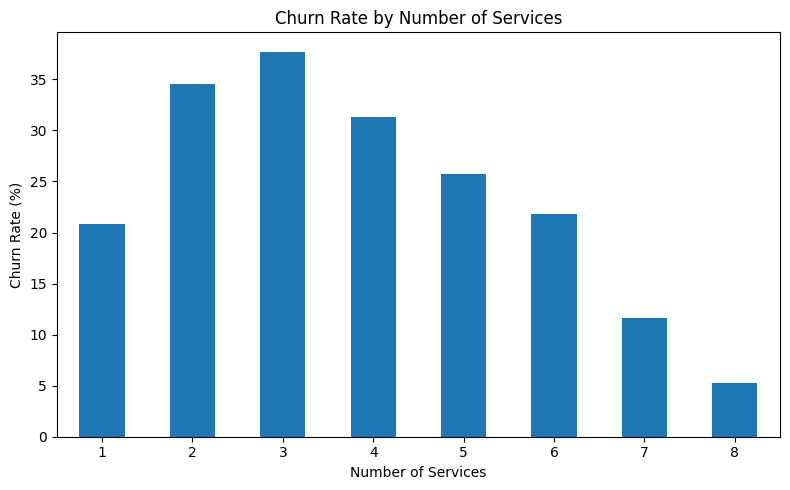

In [ ]:
# ==========================================
# TASK 5 — SERVICE & CUSTOMER SEGMENT ANALYSIS
# ==========================================

# ------------------------------------------
# 1. Churn Rate by Tech Support
# ------------------------------------------

support_churn = (
    df_clean.groupby("TechSupport")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Tech Support:")
display(support_churn.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 2. Churn Rate by Online Security
# ------------------------------------------

security_churn = (
    df_clean.groupby("OnlineSecurity")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Online Security:")
display(security_churn.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 3. Churn Rate by Contract
# ------------------------------------------

contract_churn = (
    df_clean.groupby("Contract")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract:")
display(contract_churn.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 4. Churn Rate by Customer Type
# ------------------------------------------

customer_type_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for column in customer_type_columns:

    result = (
        df_clean.groupby(column)["Churn_Flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(f"\nChurn Rate by {column}:")
    display(result.round(2).to_frame("Churn Rate (%)"))


# ------------------------------------------
# 5. Service Count
# ------------------------------------------

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Count active/additional services
df_clean["ServiceCount"] = 0

for column in service_columns:
    df_clean["ServiceCount"] += (
        ~df_clean[column].isin(["No", "No internet service"])
    ).astype(int)


# ------------------------------------------
# 6. Churn Rate by Number of Services
# ------------------------------------------

service_churn = (
    df_clean.groupby("ServiceCount")["Churn_Flag"]
    .mean()
    .mul(100)
    .sort_index()
)

print("\nChurn Rate by Number of Services:")
display(service_churn.round(2).to_frame("Churn Rate (%)"))


plt.figure(figsize=(8, 5))

service_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect("customer_churn.db")

# Store cleaned data in SQL table
df_clean.to_sql(
    "telco_churn",
    conn,
    if_exists="replace",
    index=False
)

print("SQL table created successfully!")

SQL table created successfully!


In [ ]:
# ==========================================
# TASK 6 — SQL ANALYSIS
# ==========================================

def run_sql(query):
    return pd.read_sql_query(query, conn)


# 1. Total Customers
query1 = """
SELECT COUNT(*) AS total_customers
FROM telco_churn;
"""

print("1. Total Customers")
display(run_sql(query1))


# 2. Churned Customers
query2 = """
SELECT COUNT(*) AS churned_customers
FROM telco_churn
WHERE Churn = 'Yes';
"""

print("2. Churned Customers")
display(run_sql(query2))


# 3. Overall Churn Rate
query3 = """
SELECT
    ROUND(
        100.0 * SUM(
            CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM telco_churn;
"""

print("3. Overall Churn Rate")
display(run_sql(query3))


# 4. Churn by Contract
query4 = """
SELECT
    Contract,
    COUNT(*) AS customers,
    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,
    ROUND(
        100.0 * SUM(
            CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM telco_churn
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

print("4. Churn by Contract")
display(run_sql(query4))


# 5. Average Monthly Charges by Churn
query5 = """
SELECT
    Churn,
    COUNT(*) AS customers,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM telco_churn
GROUP BY Churn;
"""

print("5. Average Monthly Charges by Churn")
display(run_sql(query5))


# 6. Churn by Internet Service
query6 = """
SELECT
    InternetService,
    COUNT(*) AS customers,
    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,
    ROUND(
        100.0 * SUM(
            CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM telco_churn
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

print("6. Churn by Internet Service")
display(run_sql(query6))


# 7. High Monthly Charge Churned Customers
query7 = """
SELECT
    customerID,
    tenure,
    Contract,
    MonthlyCharges,
    TotalCharges
FROM telco_churn
WHERE Churn = 'Yes'
AND MonthlyCharges >= 80
ORDER BY MonthlyCharges DESC
LIMIT 10;
"""

print("7. High-Charge Churned Customers")
display(run_sql(query7))

1. Total Customers


,total_customers
0,7032


2. Churned Customers


,churned_customers
0,1869


3. Overall Churn Rate


...

,Churn,customers,avg_monthly_charges
0,No,5163,61.31
1,Yes,1869,74.44


6. Churn by Internet Service


,InternetService,customers,churned_customers,churn_rate
0,Fiber optic,3096,1297,41.89
1,DSL,2416,459,19.00
2,No,1520,113,7.43


7. High-Charge Churned Customers


,customerID,tenure,Contract,MonthlyCharges,TotalCharges
0,8199-ZLLSA,67,One year,118.35,7804.15
1,2889-FPWRM,72,One year,117.80,8684.80
2,2302-ANTDP,48,Month-to-month,117.45,5438.90
3,9053-JZFKV,67,Two year,116.20,7752.30
4,1444-VVSGW,70,One year,115.65,7968.85
5,0201-OAMXR,70,One year,115.55,8127.60
6,4361-BKAXE,41,Month-to-month,114.50,4527.45
7,1555-DJEQW,70,Two year,114.20,7723.90
8,9158-VCTQB,41,Month-to-month,113.60,4594.95
9,7279-BUYWN,41,Month-to-month,113.20,4689.50


In [ ]:
# ==========================================
# TASK 7 — CHURN KPI SUMMARY
# ==========================================

total_customers = len(df_clean)

churned_customers = (
    df_clean["Churn"] == "Yes"
).sum()

churn_rate = (
    churned_customers / total_customers
) * 100

avg_monthly_charges = df_clean["MonthlyCharges"].mean()

avg_tenure = df_clean["tenure"].mean()

avg_total_charges = df_clean["TotalCharges"].mean()


# Create KPI summary
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate",
        "Average Monthly Charges",
        "Average Tenure",
        "Average Total Charges"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(avg_monthly_charges, 2),
        round(avg_tenure, 2),
        round(avg_total_charges, 2)
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Customers,7032.00
1,Churned Customers,1869.00
2,Churn Rate,26.58
3,Average Monthly Charges,64.80
4,Average Tenure,32.42
5,Average Total Charges,2283.30


Categorical Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric Features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']

Training Samples: 5625
Testing Samples: 1407

Model Accuracy:
80.45%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
[[917 116]
 [159 215]]


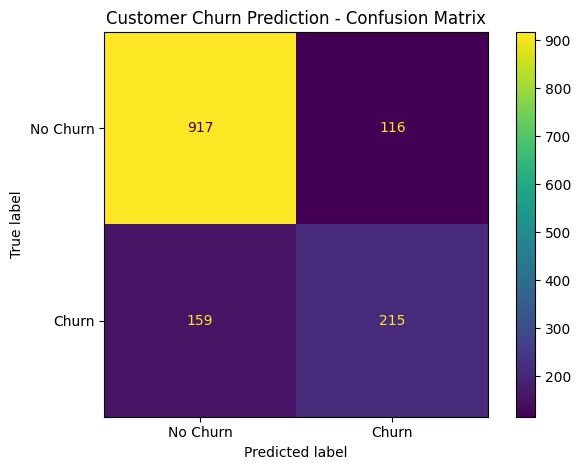

In [ ]:
# ==========================================
# TASK 8 — MACHINE LEARNING
# CUSTOMER CHURN PREDICTION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------
# 1. Prepare Features and Target
# ------------------------------------------

# Remove columns that are not useful for prediction
drop_columns = [
    "customerID",
    "Churn",
    "Churn_Flag",
    "TenureGroup"
]

X = df_clean.drop(
    columns=drop_columns,
    errors="ignore"
)

y = df_clean["Churn_Flag"]


# ------------------------------------------
# 2. Identify Column Types
# ------------------------------------------

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumeric Features:")
print(numeric_features)


# ------------------------------------------
# 3. Preprocessing
# ------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# ------------------------------------------
# 4. Create Model Pipeline
# ------------------------------------------

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


# ------------------------------------------
# 5. Train/Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ------------------------------------------
# 6. Train Model
# ------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------
# 7. Predictions
# ------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------
# 8. Model Evaluation
# ------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)


# ------------------------------------------
# 9. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

disp.plot()

plt.title(
    "Customer Churn Prediction - Confusion Matrix"
)

plt.tight_layout()
plt.show()

Top 15 Model Features:


,Feature,Coefficient,Importance
0,numeric__tenure,-1.345812,1.345812
40,categorical__Contract_Two year,-0.768144,0.768144
2,numeric__TotalCharges,0.638266,0.638266
17,categorical__InternetService_DSL,-0.635111,0.635111
38,categorical__Contract_Month-to-month,0.624126,0.624126
18,categorical__InternetService_Fiber optic,0.605550,0.605550
1,numeric__MonthlyCharges,-0.586012,0.586012
41,categorical__PaperlessBilling_No,-0.288061,0.288061
11,categorical__Dependents_Yes,-0.256693,0.256693
27,categorical__DeviceProtection_No internet service,-0.253744,0.253744


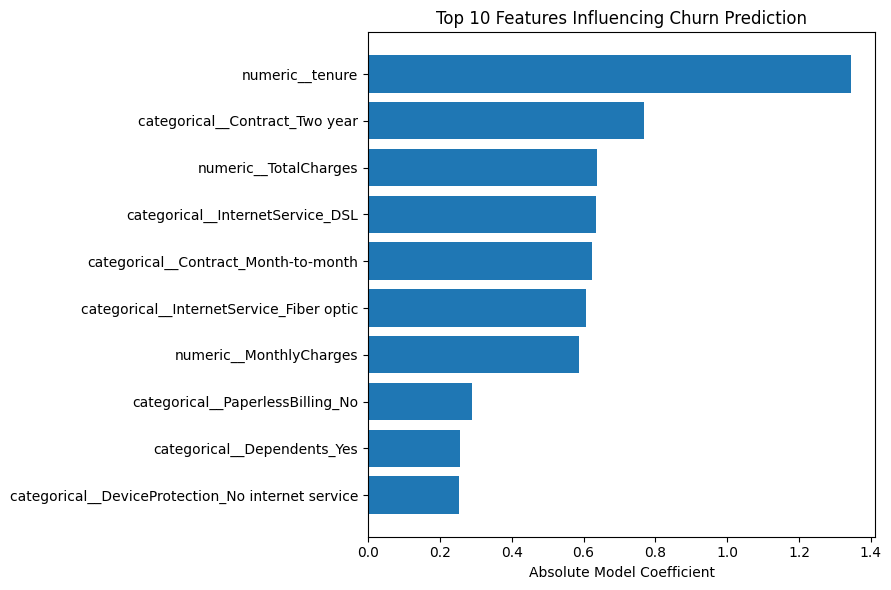

Features Associated With Higher Churn Prediction:


,Feature,Coefficient,Importance
2,numeric__TotalCharges,0.638266,0.638266
38,categorical__Contract_Month-to-month,0.624126,0.624126
18,categorical__InternetService_Fiber optic,0.605550,0.605550
3,numeric__ServiceCount,0.211278,0.211278
20,categorical__OnlineSecurity_No,0.210316,0.210316
29,categorical__TechSupport_No,0.189903,0.189903
45,categorical__PaymentMethod_Electronic check,0.186884,0.186884
34,categorical__StreamingTV_Yes,0.145706,0.145706
37,categorical__StreamingMovies_Yes,0.131647,0.131647
23,categorical__OnlineBackup_No,0.089505,0.089505


Features Associated With Lower Churn Prediction:


,Feature,Coefficient,Importance
0,numeric__tenure,-1.345812,1.345812
40,categorical__Contract_Two year,-0.768144,0.768144
17,categorical__InternetService_DSL,-0.635111,0.635111
1,numeric__MonthlyCharges,-0.586012,0.586012
41,categorical__PaperlessBilling_No,-0.288061,0.288061
11,categorical__Dependents_Yes,-0.256693,0.256693
27,categorical__DeviceProtection_No internet service,-0.253744,0.253744
21,categorical__OnlineSecurity_No internet service,-0.253744,0.253744
19,categorical__InternetService_No,-0.253744,0.253744
24,categorical__OnlineBackup_No internet service,-0.253744,0.253744


In [ ]:
# ==========================================
# TASK 9 — MODEL FEATURE IMPORTANCE
# ==========================================

# Get transformed feature names
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps[
    "classifier"
].coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute importance
feature_importance["Importance"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 15 Model Features:")

display(
    feature_importance.head(15)
)


# ------------------------------------------
# Top 10 Features Visualization
# ------------------------------------------

top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 Features Influencing Churn Prediction"
)

plt.xlabel("Absolute Model Coefficient")

plt.tight_layout()
plt.show()


# ------------------------------------------
# Positive / Negative Churn Influence
# ------------------------------------------

positive_features = (
    feature_importance[
        feature_importance["Coefficient"] > 0
    ]
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .head(10)
)

negative_features = (
    feature_importance[
        feature_importance["Coefficient"] < 0
    ]
    .sort_values(
        "Coefficient"
    )
    .head(10)
)

print("Features Associated With Higher Churn Prediction:")
display(positive_features)

print("Features Associated With Lower Churn Prediction:")
display(negative_features)

In [ ]:
# ==========================================
# TASK 10 — EXPORT DATA FOR POWER BI
# ==========================================

# Remove analysis-only columns
powerbi_df = df_clean.drop(
    columns=[
        "Churn_Flag",
        "TenureGroup"
    ],
    errors="ignore"
)

# Export cleaned dataset
powerbi_df.to_csv(
    "customer_churn_cleaned.csv",
    index=False
)

print("Power BI dataset created successfully!")
print("Rows:", powerbi_df.shape[0])
print("Columns:", powerbi_df.shape[1])

Power BI dataset created successfully!
Rows: 7032
Columns: 22


In [ ]:

# ==========================================
# CREATE ALL POWER BI DASHBOARD FILES
# ==========================================

# Check that cleaned dataset exists
print("Dataset shape:", df_clean.shape)

# Make sure Churn_Flag exists
df_clean["Churn_Flag"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

# ------------------------------------------
# 1. KPI Summary
# ------------------------------------------

total_customers = len(df_clean)

churned_customers = (df_clean["Churn"] == "Yes").sum()

churn_rate = (
    churned_customers / total_customers * 100
)

avg_monthly_charges = df_clean["MonthlyCharges"].mean()

avg_tenure = df_clean["tenure"].mean()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate",
        "Average Monthly Charges",
        "Average Tenure"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(avg_monthly_charges, 2),
        round(avg_tenure, 2)
    ]
})


# ------------------------------------------
# 2. Churn by Contract
# ------------------------------------------

dashboard_contract = (
    df_clean.groupby("Contract")
    .agg(
        Customers=("customerID", "count"),
        Churned=("Churn_Flag", "sum")
    )
    .reset_index()
)

dashboard_contract["Churn Rate (%)"] = (
    dashboard_contract["Churned"]
    / dashboard_contract["Customers"] * 100
).round(2)


# ------------------------------------------
# 3. Churn by Internet Service
# ------------------------------------------

dashboard_internet = (
    df_clean.groupby("InternetService")
    .agg(
        Customers=("customerID", "count"),
        Churned=("Churn_Flag", "sum")
    )
    .reset_index()
)

dashboard_internet["Churn Rate (%)"] = (
    dashboard_internet["Churned"]
    / dashboard_internet["Customers"] * 100
).round(2)


# ------------------------------------------
# 4. Churn by Payment Method
# ------------------------------------------

dashboard_payment = (
    df_clean.groupby("PaymentMethod")
    .agg(
        Customers=("customerID", "count"),
        Churned=("Churn_Flag", "sum")
    )
    .reset_index()
)

dashboard_payment["Churn Rate (%)"] = (
    dashboard_payment["Churned"]
    / dashboard_payment["Customers"] * 100
).round(2)


# ------------------------------------------
# 5. Churn by Tenure Group
# ------------------------------------------

df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-60 Months",
        "61-72 Months"
    ]
)

dashboard_tenure = (
    df_clean.groupby(
        "TenureGroup",
        observed=True
    )["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="Churn Rate (%)")
)


# ------------------------------------------
# EXPORT CSV FILES
# ------------------------------------------

kpi_summary.to_csv(
    "churn_kpi_summary.csv",
    index=False
)

dashboard_contract.to_csv(
    "churn_by_contract.csv",
    index=False
)

dashboard_internet.to_csv(
    "churn_by_internet_service.csv",
    index=False
)

dashboard_payment.to_csv(
    "churn_by_payment_method.csv",
    index=False
)

dashboard_tenure.to_csv(
    "churn_by_tenure.csv",
    index=False
)

print("\n✅ All dashboard files created successfully!")

print("""
churn_kpi_summary.csv
churn_by_contract.csv
churn_by_internet_service.csv
churn_by_payment_method.csv
churn_by_tenure.csv
""")

Dataset shape: (7032, 23)

✅ All dashboard files created successfully!

churn_kpi_summary.csv
churn_by_contract.csv
churn_by_internet_service.csv
churn_by_payment_method.csv
churn_by_tenure.csv



In [ ]:
# ==========================================
# TASK 11 — SAVE PROJECT OUTPUTS
# ==========================================

# Save the cleaned dataset
df_clean.to_csv(
    "customer_churn_cleaned.csv",
    index=False
)

# Save SQL analysis database
conn.commit()

# Save feature importance
feature_importance.to_csv(
    "churn_feature_importance.csv",
    index=False
)

# Save KPI summary
kpi_summary.to_csv(
    "churn_kpi_summary.csv",
    index=False
)

print("✅ Project files saved successfully!")

print("""
Main files:
• customer_churn_cleaned.csv
• churn_kpi_summary.csv
• churn_by_contract.csv
• churn_by_internet_service.csv
• churn_by_payment_method.csv
• churn_by_tenure.csv
• churn_feature_importance.csv
• customer_churn.db
""")

✅ Project files saved successfully!

Main files:
• customer_churn_cleaned.csv
• churn_kpi_summary.csv
• churn_by_contract.csv
• churn_by_internet_service.csv
• churn_by_payment_method.csv
• churn_by_tenure.csv
• churn_feature_importance.csv
• customer_churn.db

